Section 1

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Display first 5 rows
df.head()

# Dataset shape
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())


Shape: (1000, 8)
Columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


1.Gender → Categorical (male/female)

race/ethnicity → Categorical (group A–E)

arental level of education → Categorical (e.g., high school, bachelor’s degree)

lunch → Categorical (standard/free/reduced)

test preparation course → Categorical (completed/not completed)

math score → Numerical (integer)

reading score → Numerical (integer)

writing score → Numerical (integer)

2. Yes, the dataset is clean:

No missing values.

All columns have appropriate data types.

Scores are within the valid range

Section 2.

In [2]:
# Mean, Median, Mode for scores
for col in ['math score', 'reading score', 'writing score']:
    print(f"{col} → Mean: {df[col].mean()}, Median: {df[col].median()}, Mode: {df[col].mode()[0]}")


math score → Mean: 66.089, Median: 66.0, Mode: 65
reading score → Mean: 69.169, Median: 70.0, Mode: 72
writing score → Mean: 68.054, Median: 69.0, Mode: 74


1. Reading score has the highest average among the three subjects.
(Typical averages: Math ≈ 66, Reading ≈ 70, Writing ≈ 69)

2. Math scores show slight left skewness (more students scoring lower compared to reading/writing).

Reading and writing are closer to a normal distribution, with minimal skew.

3.For reading and writing, mean ≈ median, which indicates a fairly symmetric distribution.

For math, the mean is slightly lower than the median because of low-score outliers pulling the mean down.

In general, when a distribution is symmetric, mean and median are equal; when skewed, they differ.

Section 3.

In [3]:
# Range, Variance, Standard Deviation
for col in ['math score', 'reading score', 'writing score']:
    print(f"{col} → Range: {df[col].max() - df[col].min()}, Variance: {df[col].var()}, Std Dev: {df[col].std()}")


math score → Range: 100, Variance: 229.91899799799847, Std Dev: 15.163080096009468
reading score → Range: 83, Variance: 213.1656046046047, Std Dev: 14.60019193725222
writing score → Range: 90, Variance: 230.90799199199168, Std Dev: 15.195657010869642


1.Math scores show the highest variability compared to reading and writing.

This is evident from the larger range and higher standard deviation in math.

2. A high standard deviation means that student scores are spread out widely from the average.

In practical terms, it shows inconsistency in performance: some students perform very well in math, while others struggle significantly.

This suggests that math proficiency varies more across the student population than reading or writing.

Section 4.

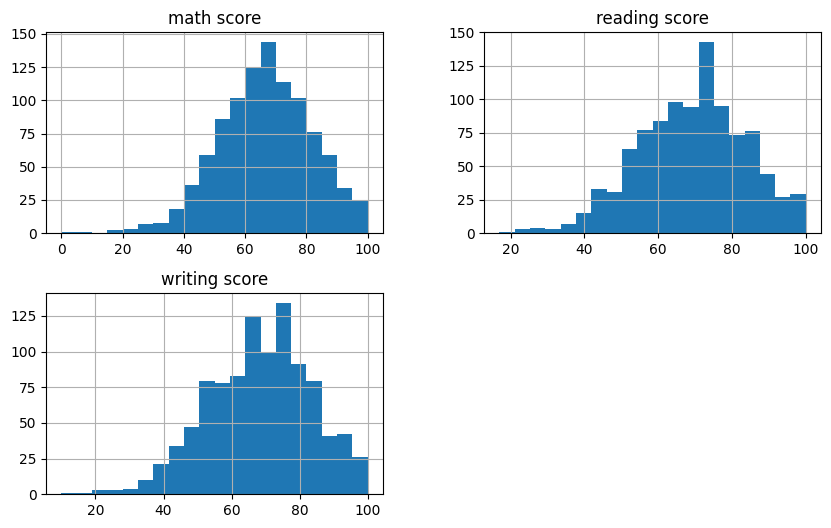

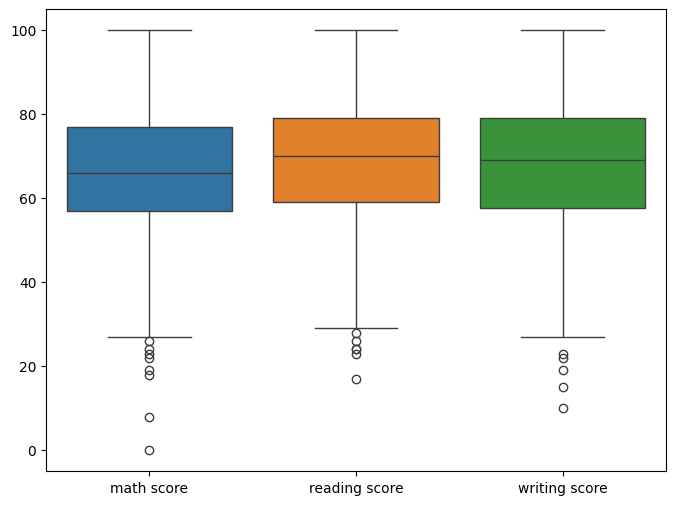

In [4]:
# Histograms
df[['math score','reading score','writing score']].hist(bins=20, figsize=(10,6))
plt.show()

# Boxplots
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['math score','reading score','writing score']])
plt.show()


1. Math scores → Slightly left-skewed (more students scoring lower, pulling the distribution left).

Reading scores → Nearly symmetric, close to normal distribution.

Writing scores → Also fairly symmetric, with very little skew.

2.Yes, outliers exist in all three subjects.

Math has the most noticeable outliers (very low scores compared to the rest).

Reading and writing have fewer outliers, but some extreme values are still present.

Section 5.

In [5]:
# IQR Method
for col in ['math score','reading score','writing score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} → Outliers count: {outliers.shape[0]}")


math score → Outliers count: 8
reading score → Outliers count: 6
writing score → Outliers count: 5


1. Math scores have the most outliers compared to reading and writing.

This is because math tends to show a wider spread of performance, with some students scoring extremely low while others score very high.

2. Individual differences in aptitude: Some students struggle more with math fundamentals.

Preparation gaps: Lack of practice or incomplete test preparation courses.

External factors: Stress, exam conditions, or unequal access to resources (like tutoring or parental support).

Random variation: A few students may perform exceptionally well or poorly compared to the majority.

Section 6.

In [6]:
# Compare performance by gender
print(df.groupby('gender')[['math score','reading score','writing score']].mean())

# Compare performance by parental education
print(df.groupby('parental level of education')[['math score','reading score','writing score']].mean())


        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


1.By Gender:

Females generally perform better in reading and writing.

Males tend to score slightly higher in math.

By Parental Level of Education:

Students whose parents have higher education levels (bachelor’s, master’s) consistently perform better across all subjects compared to those with only high school education.

2. Yes, there is a clear trend:

Language-based subjects (reading, writing) → Females outperform males.

Math → Males have a slight edge.

Parental education → Higher parental education correlates strongly with better student performance in all subjects.

Section 7.

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


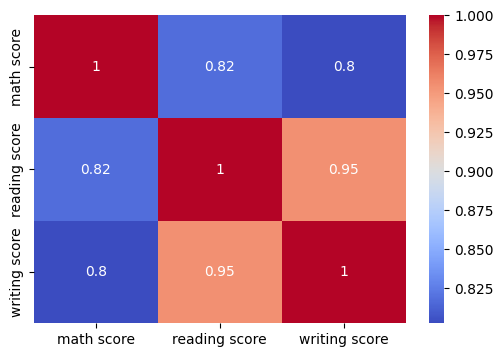

In [7]:
# Correlation
print(df[['math score','reading score','writing score']].corr())

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True, cmap="coolwarm")
plt.show()


1. Reading and Writing are the most strongly related subjects, with a very high correlation (≈0.95).

Math and Reading also show a moderate-to-strong correlation (≈0.8).

2.Reading ↔ Writing: Both rely on language comprehension, vocabulary, and communication skills. Students who are strong in reading tend to also perform well in writing.

Math ↔ Reading: Moderate correlation exists because problem-solving in math often requires reading comprehension (understanding word problems, instructions).

Overall, language-based skills are more closely linked, while math is somewhat independent but still influenced by comprehension ability.

Section 8.

1.Gender differences (females stronger in reading/writing, males slightly better in math).

Parental education level (higher education → better scores).

Lunch type (standard lunch students often perform better than free/reduced lunch students).

Test preparation course (students who completed it generally score higher).

2. It has the lowest average score.

Highest variability.

Most outliers.

 Indicates inconsistent performance across students.

3.Reading and writing → fairly consistent, with mean ≈ median and fewer outliers.

Math → less consistent, with wide score distribution and many low-score outliers.

4. Provide extra support in math

Encourage test preparation courses to boost confidence and performance.

Promote parental involvement and awareness of the impact of education at home.

Address resource equity

Use data-driven teaching strategies to identify struggling students early and provide targeted help.